# Notebook with plots for paper _Virtual Distillation for bosonic systems_

This notebook is used to produce part of the plots appearing in the final version of the paper. It relies on the auxiliary functions from the file ```paper_functions.py```.

In [49]:
import qutip
import numpy as np
import math
import matplotlib.pyplot as plt
#import matplotlib.colors as colors
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from paper_functions import *

colors= [ #color blind friendly list
    "#F5B34C",  # orange
    "#E986DF",  # pinkish
    "#021373", #darkblue
    "#C22C1E",  # red
    "#009B9E",  # teal
    "#7f7f7f",  # gray
    "#4ADA75",  # green 
    "#F5D596", #lightorange
    "#935EEB",  # purple
    "#F23064",  # sete pink
    "#F58C56", #brick orange
    ]    

## I. Theoretical results for number operator

We start by considering three kinds of ideal states: Fock state $\ket3$, binomial state $\frac{1}{\sqrt{2}}(\ket{0} + \ket{4})$, and cat state $\propto \ket{\alpha} + \ket{-\alpha}$.

We let each ideal state evolve through a loss channel for different times, to get our input states for the virtual distillation protocol. We then compute the expectation value for the number operator $\hat n$ and compare the results of no-VD, 2-mode VD, 3-mode VD and 4-mode VD.

In [50]:
### Numerical parameters ###

N = 20 # Hilbert space dimension of one bosonic mode (truncated at N-1 excitations)

T_1 = 500 # μs
decay_rate = 1/T_1 # decay rate κ of the cavity (only for losses)

t_max = 100 # μs (such that κt ~ 0.2)
nb_samples = 40
t_list = np.linspace(0,t_max,nb_samples)

In [51]:
rho_fock_pure = qutip.fock_dm(N, 3)
rho_binomial_pure = qutip.ket2dm((qutip.fock(N,0) + qutip.fock(N,4)).unit())
alpha = 1.0
rho_cat_pure = qutip.ket2dm((qutip.coherent(N, alpha) + qutip.coherent(N, -alpha)).unit())

rho_pure_list = [ (rho_fock_pure, 'Fock state $|3⟩$'), (rho_binomial_pure, 'Binomial state'), (rho_cat_pure, 'Cat state') ]
rho_noisy_list = create_noisy_list(N, loss_channel, decay_rate, t_list, rho_pure_list)

observable, observable_label = qutip.num(N), '$\\langle\\hat{n}\\rangle$'
M_list = [(1, 'no distillation')] + [(M, f'${M}$-mode VD') for M in [2,3,4]]

results = np.real_if_close(perform_protocol(N, rho_noisy_list, M_list, observable))

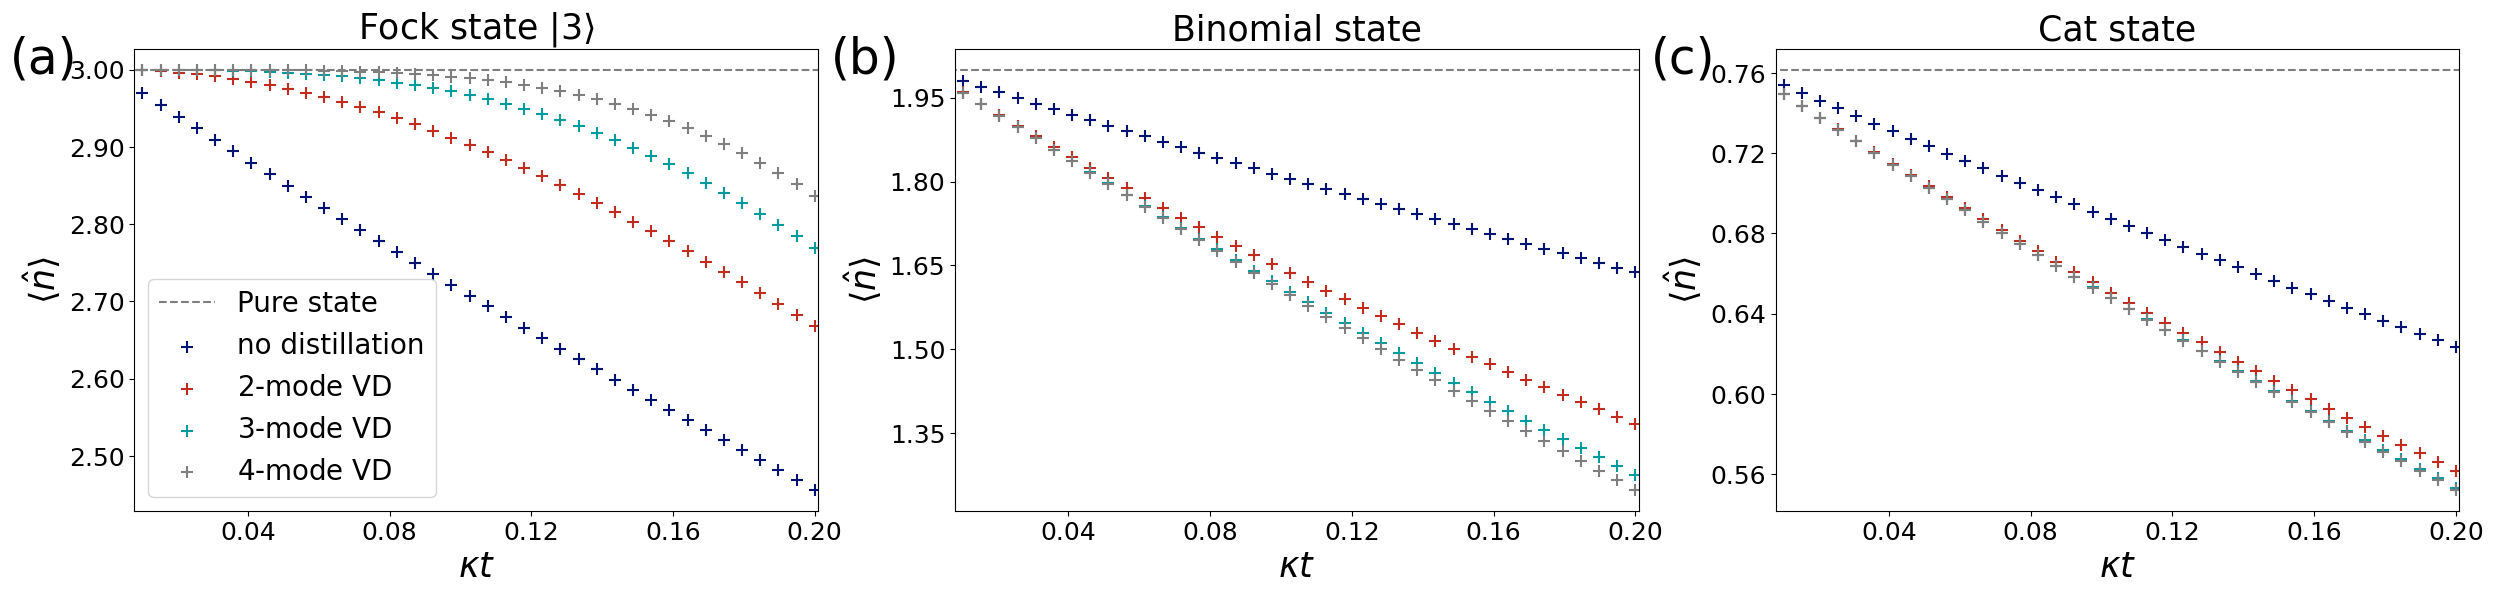

In [52]:
fig, ax = plt.subplots(1, results.shape[0], figsize=(10*results.shape[0],6))
plot_theoretical_results(fig, ax, results, rho_noisy_list, M_list, t_list, observable_label, (decay_rate, "kappa"),
            plot_params = {'colors': colors, 'show_wigner': False, 
                           'legend_loc': 'inside bottom',
                           'legend_font_size': 20,
                           'xmin': 0.008, 'xmax': 0.201,
                            'labels': ['(a)', '(b)', '(c)'],})
plt.savefig('plots/Fock_Binom_cat.pdf', bbox_inches='tight')
plt.show()

## II. Parity operator on even, tri and square cat


Same thing with parity operator measurement $(-1)^{\hat n}$, tested on input even, tri and cat states with losses.
$$\ket{\psi_\text{even}} \propto \ket\alpha + \ket{-\alpha} $$
$$\ket{\psi_\text{tri}} \propto \ket\alpha + \ket{e^{2i\pi/3}\alpha} + \ket{e^{-2i\pi/3}\alpha}$$
$$\ket{\psi_\text{square}} \propto \ket\alpha + \ket{i\alpha}+\ket{-\alpha} + \ket{-i\alpha} $$


In [53]:
alpha = 1.50
rho_even_pure = qutip.ket2dm((qutip.coherent(N, alpha) + qutip.coherent(N, -alpha)).unit())
rho_tri_pure = qutip.ket2dm((qutip.coherent(N, alpha) + qutip.coherent(N, alpha*np.exp(2j*np.pi/3)) + qutip.coherent(N, alpha*np.exp(4j*np.pi/3))).unit())
rho_square_pure = qutip.ket2dm((qutip.coherent(N, alpha) + qutip.coherent(N, alpha*1j) + qutip.coherent(N, -alpha) + qutip.coherent(N, -alpha*1j)).unit())

rho_pure_list = [ (rho_even_pure, "Even cat state"), (rho_tri_pure, "Tri cat state"), (rho_square_pure, "Square cat state") ]

rho_noisy_list = create_noisy_list(N, loss_channel, decay_rate, t_list, rho_pure_list)

observable = (1j*np.pi*qutip.num(N)).expm() # Parity operator
observable_label = '$\\langle e^{i\\pi\\hat{n}}\\rangle$'
M_list = [(1, 'no distillation')] + [(M, f'${M}$-mode VD') for M in [2,3,4]]

results = np.real_if_close(perform_protocol(N, rho_noisy_list, M_list, observable))

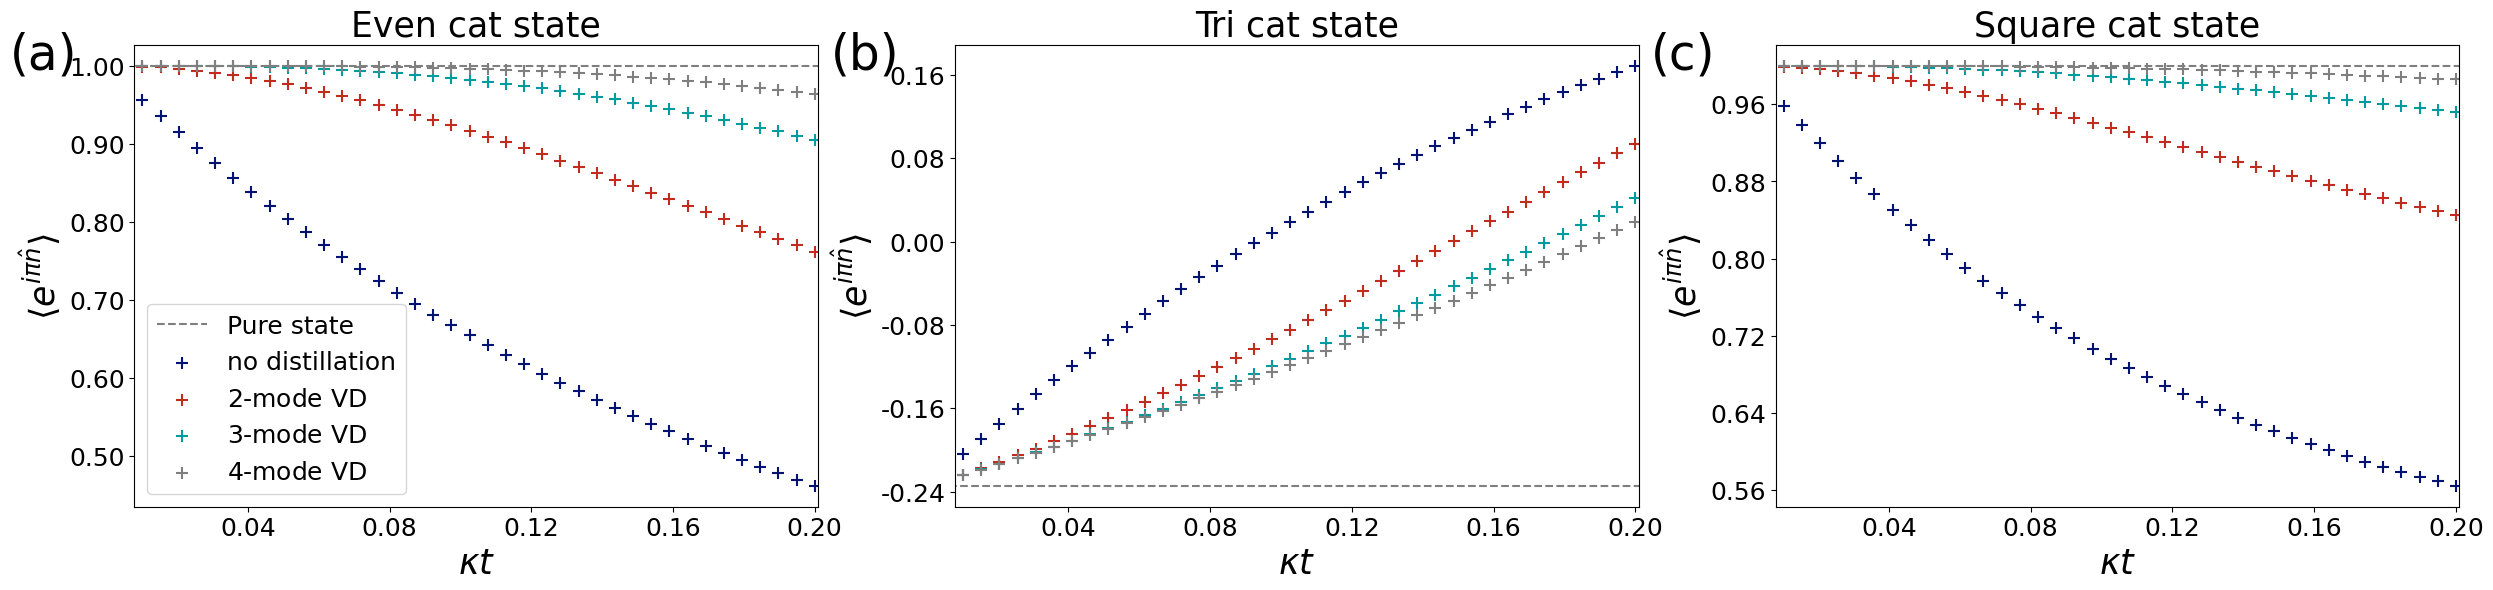

In [54]:
fig, ax = plt.subplots(1, results.shape[0], figsize=(10*results.shape[0],6))
plot_theoretical_results(fig, ax, results, rho_noisy_list, M_list, t_list, observable_label, (decay_rate, "kappa"),
            plot_params = { 'colors': colors, 'show_wigner': False, 
                           'legend_loc': 'inside bottom',
                           'legend_font_size': 18,
                           'xmin': 0.008, 'xmax': 0.201,
                            'labels': ['(a)', '(b)', '(c)']})

plt.savefig('plots/even_tri_square.pdf', bbox_inches='tight')
plt.show()

## III. Theoretical results for quadrature operator

We measure the two quadrature operators $\hat q$ and $\hat p$, on squeezed coherent states with dephasing noise.

In [ ]:
### Numerical parameters ###

N = 20

T_2 = 600 # μs
dephasing_rate = 1/T_2 # dephasing rate γ of the cavity

t_max = 200 # μs (such that γt ~ 0.33)
nb_samples = 40
t_list = np.linspace(0,t_max,nb_samples)

In [56]:
alpha = 0.3 + 0.3j
rho_1_pure = qutip.ket2dm(qutip.squeeze(N, 0.5) * qutip.coherent(N, alpha)) # squeezed with 0.5 in q
rho_2_pure = qutip.ket2dm(qutip.squeeze(N, -0.5)*qutip.coherent(N, alpha)) #squeezed with -0.5 in q (i.e. 0.5 in p)

rho_pure_list = [ (rho_1_pure, '$q$-squeezed'), (rho_2_pure, '$p$-squeezed') ]
rho_noisy_list = create_noisy_list(N, dephasing_channel, dephasing_rate, t_list, rho_pure_list)

observable_q = (qutip.destroy(N) + qutip.create(N)) / np.sqrt(2) # quadrature operator q
observable_q_label = '$\\langle\\hat{q}\\rangle$'

observable_p = (qutip.destroy(N) - qutip.create(N)) / (1j * np.sqrt(2)) # quadrature operator p
observable_p_label = '$\\langle\\hat{p}\\rangle$'

M_list = [(1, 'no distillation')] + [(M, f'${M}$-mode VD') for M in [2,3,4]]

results_l = [] # combine both quadratures in the same list
for h, observable in enumerate([observable_q, observable_p]):
    results_l.append(np.real_if_close(perform_protocol(N, rho_noisy_list, M_list, observable)))

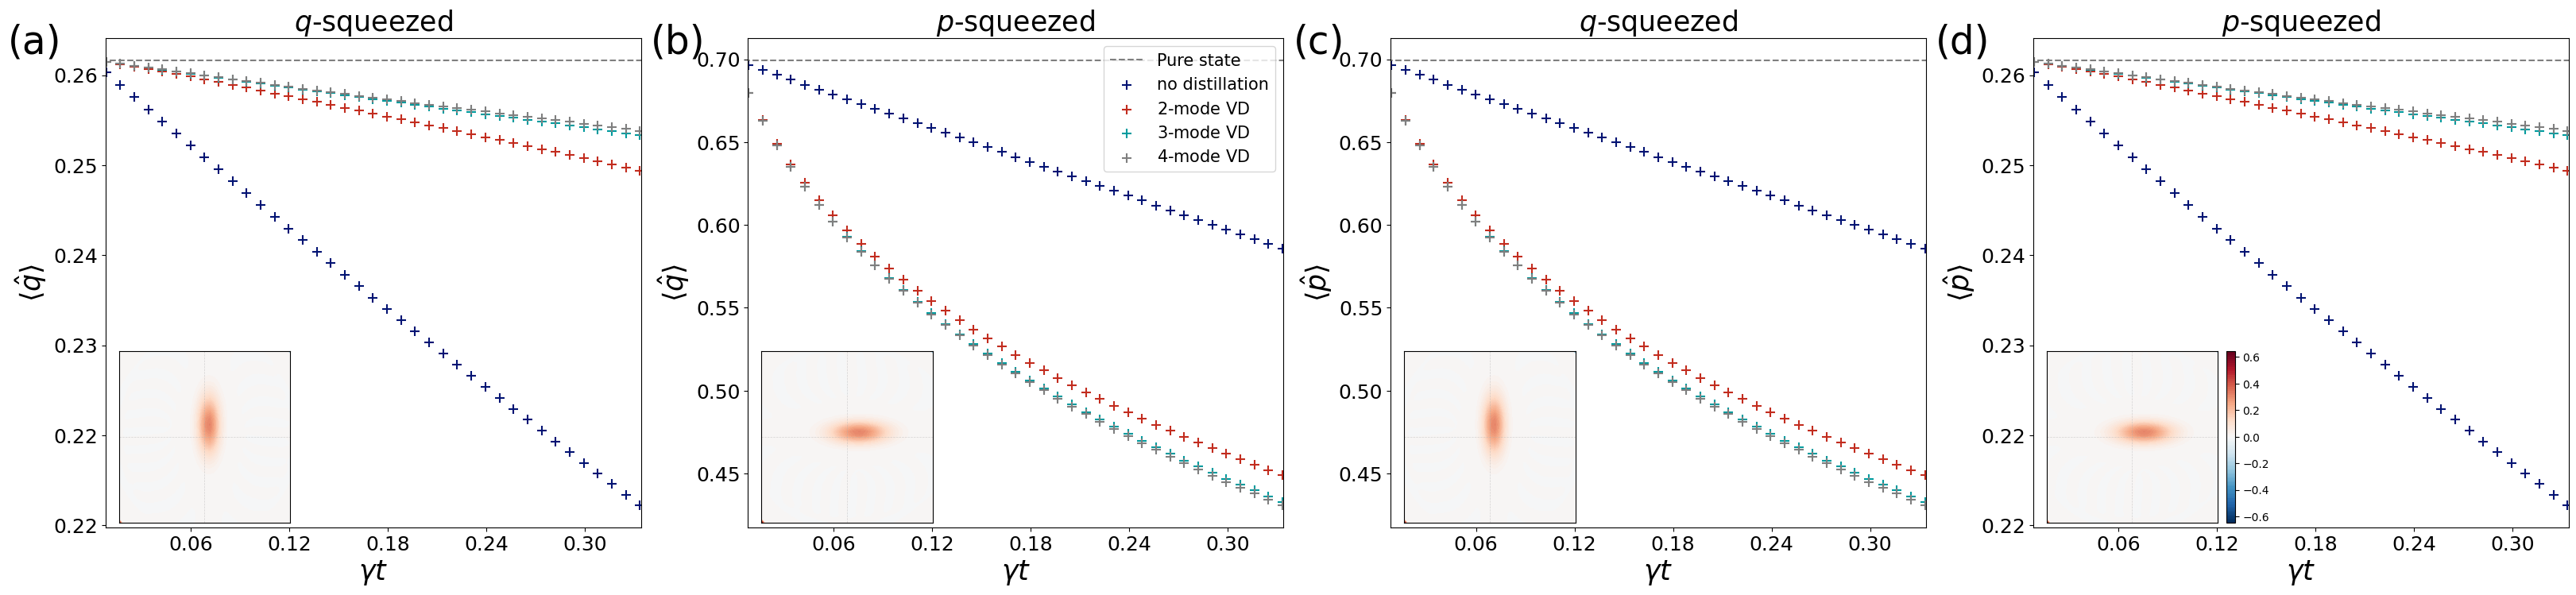

In [57]:
nb_v, nb_h = 1, 4
fig, ax = plt.subplots(nb_v, nb_h, figsize=(10*nb_h, 8))

ax_0 = ax[:2] # first two columns for q
plot_theoretical_results(fig, ax_0, results_l[0], rho_noisy_list, M_list, t_list, observable_q_label, (dephasing_rate, "gamma"),
    plot_params = {'colors': colors,
                    'show_wigner': True, 
                    'legend_loc': 'inside last',
                    'xmin': 0.008, 'xmax': 0.334,
                    'tick_list' : [-5, 0, 5],
                    'tick_params': {'axis':'both', 'which':'both','bottom':False, 'top':False,'left':False, 'right':False, 'labelbottom':False, 'labelleft':False},
                    'labels': ['(a)', '(b)'],
                    'wigner_cmap': 'RdBu_r',
                    'wigner_vmax': 2/np.pi,
                    'idx_wigner_colorbar': 2})

ax_1 = ax[2:] # last two columns for p
plot_theoretical_results(fig, ax_1, results_l[1], rho_noisy_list, M_list, t_list, observable_p_label, (dephasing_rate, "gamma"),
            plot_params = { 'colors': colors,
                    'show_wigner': True, 
                    'legend_loc': 'none',
                    'xmin': 0.008, 'xmax': 0.334,
                    'tick_list' : [-5, 0, 5],
                    'tick_params': {'axis':'both', 'which':'both','bottom':False, 'top':False,'left':False, 'right':False, 'labelbottom':False, 'labelleft':False},
                    'labels': ['(c)', '(d)'],
                    'wigner_cmap': 'RdBu_r',
                    'wigner_vmax': 2/np.pi,
                    'idx_wigner_colorbar': 1})

plt.savefig('plots/q_squeezed_p_squeezed.pdf', bbox_inches='tight') #, pad_inches=0)
plt.show() 

## IV. Adding noise to the protocol (M=3)

We consider Fock states with losses and number operator measurements. We add coherent noise in the beam splitters, interleaved losses and interleaved dephasing.
This requires more work, since we base the noise analysis on an actual implementation with the 3-mode Fourier interferometer. States are now matrices of size $N^3\times N^3$ and it takes some time to compute the associated quantum gates.

We also need to sample on different noise values to have error bars that make sense.

In [58]:
### Numerical parameters ###

#N = 5 # 9 # More than 9 takes too long and less than 9 gives weird behaviors (the shift operator does not work for |3>)
N=6 #is the min for |2>

T_1 = 500 # μs
decay_rate_mean = 1/T_1 # average decay rate κ of the cavity (only for losses)
decay_rate_std = decay_rate_mean*0.03 # we consider a 3% variability in the decay rate, gaussian distributed

T_2 = 600 # μs
dephasing_rate_mean = 1/T_2 # average dephasing rate γ of the cavity
dephasing_rate_std = dephasing_rate*0.03

eps_std = np.pi/4 * 0.03 # coherent error in the beam splitters

interleaved_time = 10 # μs time between each gate in the protocol

nb_protocol_samples = 100 # for each input we perform the protocol a few times to have the corresponding error bar

t_max = 100 # μs (such that κt ~ 0.2)
nb_t_samples = 15 # 20
t_list = np.linspace(0,t_max,nb_t_samples)

In [59]:
np.random.seed(0) # for reproducibility
recalc = False
try:
    results_err = np.load('data/results_err.npy')
except:
    recalc = True

In [60]:
n = 2 # 3
rho_fock_pure = qutip.fock_dm(N, n)

# We create the list of noisy states (ON THE FULL 3-MODE SYSTEM): rho_tot_list[i][j] is the j-th sample at time t_list[i], ie a matrix of size (N^3, N^3)
# We cannot use super operators since they are too big

if recalc:
    rho_tot_list = compute_noisy_states_losses(N, t_list, rho_fock_pure, nb_protocol_samples, decay_rate_mean, decay_rate_std, nb_copies=3, print_progress=True)

In [61]:
initial_sin_angles = np.sqrt((1/2,1/2,1/3)) # exact values
noise_list = np.random.normal(0,eps_std,(nb_t_samples, nb_protocol_samples, 3))

# Here we precompute the quantum gates corresponding to the Fourier interferometer
if recalc:
    F_list = create_F3_list(N, initial_sin_angles, noise_list, print_progress=True)

In [62]:
rho_pure_list = [ (qutip.fock_dm(N, n), '')] #f'Fock state $|{n}⟩$ with errors ({nb_protocol_samples} samples)') ] 
rho_noisy_list = create_noisy_list(N, loss_channel, decay_rate_mean, t_list, rho_pure_list)

observable = qutip.num(N)
observable_label = '$\\langle\\hat{n}\\rangle$'
M_list = [(1, 'no distillation')] + [(3, '$3$-mode VD')] #[(1, 'no distillation')] + [(M, f'${M}$-mode VD') for M in [2,3,4]]

# final operators measured in the protocol
n1 = qutip.tensor(qutip.num(N),  qutip.identity(N), qutip.identity(N))
n2 = qutip.tensor(qutip.identity(N), qutip.num(N),  qutip.identity(N))
n3 = qutip.tensor(qutip.identity(N), qutip.identity(N), qutip.num(N))
den_op = (2j*np.pi/3*(n1+2*n2)).expm()
num_op = (n1+n2+n3)/3 * den_op


results_th = np.real_if_close(perform_protocol(N, rho_noisy_list, M_list, observable))

if recalc:
    results_err = perform_protocol_errors(N, rho_tot_list, F_list, decay_rate_mean, decay_rate_std,
                                  dephasing_rate_mean, dephasing_rate_std, interleaved_time, [num_op, den_op], print_progression=True)
#results_err.shape

In [63]:
if recalc:
    np.save('data/results_err.npy', results_err)

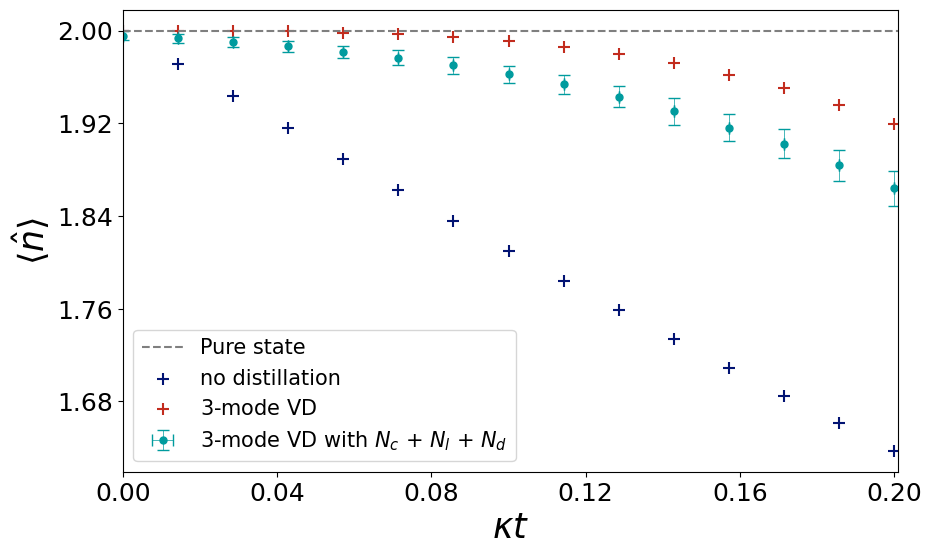

In [64]:
fig, ax = plt.subplots(1,1, figsize=(10,6))

ax.errorbar(decay_rate_mean*t_list, np.abs(results_err.mean(1)), results_err.std(1), np.zeros_like(t_list), 
                    barsabove=True, elinewidth=.5,fmt='.',
                    label="3-mode VD with $N_c$ + $N_l$ + $N_d$",
                    c=colors[4], ms=10,capsize=4)

plot_theoretical_results(fig, [ax], results_th, rho_noisy_list, M_list, t_list, observable_label, (decay_rate, "kappa"),
            plot_params = {'colors': colors, 'show_wigner': False, 'legend_loc': 'inside bottom',
                           'xmin': 0, 'xmax': 0.201, 'labels': ['']})
plt.savefig('plots/Fock_with_errors.pdf', bbox_inches='tight')
plt.show()